Setup Image paths

In [13]:
import os
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import time

Define root directory

In [14]:
root_dir = 'C:/Users/brian/Documents/SPRING 2025/BMED 6780/Project/archive/archive/openEDS/openEDS/'

image_paths = []
labels = []

Collect and Organize image-Label Pairs

In [15]:
# -------------------
# 1. Collect image paths and labels
# -------------------

for subfolder in os.listdir(root_dir):
    subfolder_path = os.path.join(root_dir, subfolder)
    if os.path.isdir(subfolder_path):
        for file in os.listdir(subfolder_path):
            if file.endswith('.png'):
                base_name = os.path.splitext(file)[0]  # e.g., '0' from '0.npy'
                png_file = base_name + '.png'
                png_path = os.path.join(subfolder_path, png_file)

                if not os.path.isfile(png_path):
                    continue

                try:
                    image_paths.append(png_path)

                except Exception as e:
                    print(f"Skipping corrupted or invalid file: {file}")
                    print(e)
                    continue

# Final report
print(f"\nTotal image-label pairs collected: {len(image_paths)}")


Total image-label pairs collected: 27431


Pre-processing steps:
- Fixed gamma correction with an exponent of 0.8
- local Contrast Limited Adaptive Histogram Equalization (CLAHE) with a grid size of 8x8 and clip limit value of 1.5. (Modified to percentile stretch, 1% mapping to 0, 99% mapping to 255)

Gamma via LUT: 0.00 ms
Percentile Stretch via LUT: 0.00 ms


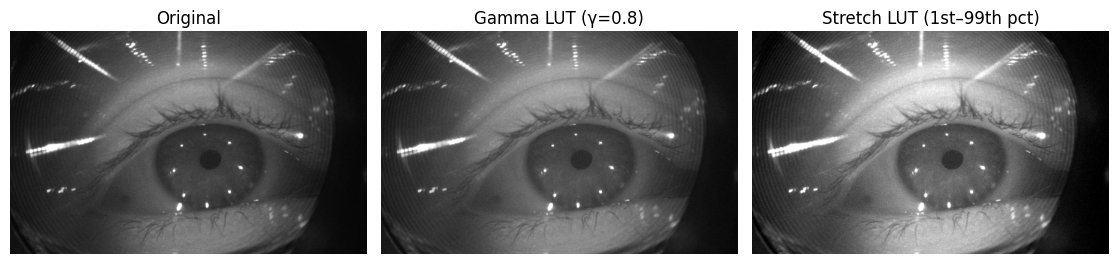

In [16]:
# ——————— Setup ———————
# Make sure image_paths defined
img_path = image_paths[0].replace('\\', '/')
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Could not load image from: {img_path}")

# ——————— 1) Gamma via LUT ———————
gamma = 0.8
# Precompute 256-entry LUT
gamma_LUT = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

start = time.time() # measure execution time
# Apply LUT to the image
gamma_corrected = cv2.LUT(img, gamma_LUT)
time_gamma = (time.time() - start) * 1000
print(f"Gamma via LUT: {time_gamma:.2f} ms")

# ——————— 2) Percentile Stretch via LUT ———————
# Compute percentiles on the gamma‐corrected image
p_low, p_high = np.percentile(gamma_corrected, (1, 99))

# Build a 256-entry stretch LUT so that:
#   values ≤ p_low  → 0
#   values ≥ p_high → 255
#   in between       → linearly scaled
stretch_LUT = np.zeros(256, dtype=np.uint8)
scale = 255.0 / max((p_high - p_low), 1)
for i in range(256):
    if i <= p_low:
        stretch_LUT[i] = 0
    elif i >= p_high:
        stretch_LUT[i] = 255
    else:
        stretch_LUT[i] = np.uint8((i - p_low) * scale)

start = time.time()
stretched = cv2.LUT(gamma_corrected, stretch_LUT)
time_stretch = (time.time() - start) * 1000
print(f"Percentile Stretch via LUT: {time_stretch:.2f} ms")

'''
# ——————— 3) Local Mean Subtraction ———————
def local_mean_subtract(im, win=32):
    H, W = im.shape
    integral = cv2.integral(im)
    out = np.zeros_like(im, dtype=np.float32)
    half = win // 2
    for y in range(H):
        y1, y2 = max(0, y-half), min(H, y+half)
        for x in range(W):
            x1, x2 = max(0, x-half), min(W, x+half)
            area = (y2 - y1) * (x2 - x1)
            s = integral[y2, x2] - integral[y1, x2] - integral[y2, x1] + integral[y1, x1]
            mean = s / area
            out[y, x] = im[y, x] - mean
    out = cv2.normalize(out, None, 0, 255, cv2.NORM_MINMAX)
    return out.astype(np.uint8)

start = time.time()
enhanced = local_mean_subtract(stretched, win=32)
time_lms = (time.time() - start) * 1000
print(f"Local Mean Subtraction (win=32): {time_lms:.2f} ms")
'''

# ——————— Plot preprocessing results on a sample image ———————
plt.figure(figsize=(15, 5))
for i, (im, title) in enumerate([
    (img, "Original"),
    (gamma_corrected, f"Gamma LUT (γ={gamma})"),
    (stretched, "Stretch LUT (1st–99th pct)")#, #toggle for local mean subtraction
    #(enhanced,  "Local Mean Subtraction")
], 1):
    plt.subplot(1, 4, i)
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [52]:
# ——————— Performance Masurement  ———————

# assuming image_paths already defined

# -------------------
# 1. Profile preprocessing steps on a sample of images
# -------------------
N = 1000  # number of frames to sample
gamma = 0.8
# Precompute Gamma LUT
gamma_LUT = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
# Pre-create CLAHE
clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))

times = {'Gamma LUT': [], 'Stretch LUT': [], 'CLAHE': []}

for path in image_paths[:N]:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # Gamma LUT
    start = time.time()
    gamma_corr = cv2.LUT(img, gamma_LUT)
    times['Gamma LUT'].append((time.time() - start) * 1000)

    # Percentile Stretch LUT
    p_low, p_high = np.percentile(gamma_corr, (1, 99))
    scale = 255.0 / max((p_high - p_low), 1)
    stretch_LUT = np.array([0 if i <= p_low else 255 if i >= p_high else (i - p_low) * scale
                             for i in range(256)], dtype=np.uint8)
    start = time.time()
    _ = cv2.LUT(gamma_corr, stretch_LUT)
    times['Stretch LUT'].append((time.time() - start) * 1000)

    # CLAHE apply
    start = time.time()
    _ = clahe.apply(gamma_corr)
    times['CLAHE'].append((time.time() - start) * 1000)

# -------------------
# 2. Compute and display statistics
# -------------------
stats = []
for step, vals in times.items():
    stats.append({
        'Step': step,
        'Mean Time (ms)': np.mean(vals),
        'Std Time (ms)': np.std(vals)
    })

df = pd.DataFrame(stats)
print(df.to_string(index=False))

# Throughput (FPS)
lut_total = df.loc[df['Step'].isin(['Gamma LUT', 'Stretch LUT']), 'Mean Time (ms)'].sum()
fps_lut = 1000.0 / lut_total
fps_clahe = 1000.0 / df.loc[df['Step'] == 'CLAHE', 'Mean Time (ms)'].values[0]

print(f"\nLUT Pipeline (Gamma + Stretch) FPS: {fps_lut:.1f}")
print(f"CLAHE-only FPS: {fps_clahe:.1f}")

# Memory Footprint
lut_storage = 2 * 256  # two 256-entry LUTs of 1 byte each
clahe_hist_bytes = 8 * 8 * 256 * 4  # 8x8 grid, 256 bins, 4 bytes per bin (float)
print(f"\nMemory Footprint:")
print(f"  LUT storage: {lut_storage} bytes")
print(f"  CLAHE histogram buffers: {clahe_hist_bytes} bytes")

       Step  Mean Time (ms)  Std Time (ms)
  Gamma LUT        0.034739       0.317124
Stretch LUT        0.114770       1.082791
      CLAHE        0.314885       1.450145

LUT Pipeline (Gamma + Stretch) FPS: 6688.6
CLAHE-only FPS: 3175.8

Memory Footprint:
  LUT storage: 512 bytes
  CLAHE histogram buffers: 65536 bytes


In [ ]:
import cv2
import numpy as np
import time
import pandas as pd

# NOTE: This code assumes that the image paths are already defined in `image_paths`.\
# Make sure to pip install tabulate if you want to use the tabulate library for pretty printing.

# Path to the test image
img_path = image_paths[0].replace('\\', '/')
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Could not load image from: {img_path}")

# Precompute gamma LUT (γ = 0.8)
gamma = 0.8
gamma_LUT = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

# Compute stretch LUT based on gamma-corrected image
gamma_corrected = cv2.LUT(img, gamma_LUT)
p_low, p_high = np.percentile(gamma_corrected, (1, 99))
scale = 255.0 / max((p_high - p_low), 1)
stretch_LUT = np.array([
    0 if i <= p_low else 255 if i >= p_high else np.uint8((i - p_low) * scale)
    for i in range(256)
], dtype=np.uint8)

# Prepare CLAHE (on gamma-corrected image)
clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))

# Benchmarking
N = 100
times = {"Gamma LUT": [], "Stretch LUT": [], "CLAHE on Gamma": []}

# Warm-up
_ = cv2.LUT(img, gamma_LUT)
_ = cv2.LUT(gamma_corrected, stretch_LUT)
_ = clahe.apply(gamma_corrected)

for _ in range(N):
    # Gamma LUT
    start = time.time()
    g = cv2.LUT(img, gamma_LUT)
    times["Gamma LUT"].append((time.time() - start) * 1000)
    
    # Stretch LUT
    start = time.time()
    s = cv2.LUT(g, stretch_LUT)
    times["Stretch LUT"].append((time.time() - start) * 1000)
    
    # CLAHE on gamma-corrected
    start = time.time()
    _ = clahe.apply(g)
    times["CLAHE on Gamma"].append((time.time() - start) * 1000)

# Compile performance table
perf_data = []
for method, vals in times.items():
    mean_ms = np.mean(vals)
    std_ms = np.std(vals)
    fps = 1000.0 / mean_ms if mean_ms > 0 else np.nan
    perf_data.append({
        "Method": method,
        "Mean Time (ms)": f"{mean_ms:.2f}",
        "Std Dev (ms)": f"{std_ms:.2f}",
        "FPS": f"{fps:.0f}"
    })

df_perf = pd.DataFrame(perf_data)
print("### Performance Comparison (N=100)\n")
print(df_perf.to_markdown(index=False))

# Memory footprint comparison
mem_lut = gamma_LUT.nbytes + stretch_LUT.nbytes  # bytes
tiles = 8 * 8
mem_clahe = tiles * 256 * np.dtype(np.int32).itemsize  # bytes

df_mem = pd.DataFrame([
    {"Component": "Two 256-entry LUTs", "Memory (bytes)": mem_lut},
    {"Component": "CLAHE histograms (8x8 tiles)", "Memory (bytes)": mem_clahe}
])
print("\n### Memory Footprint Comparison\n")
print(df_mem.to_markdown(index=False))



### Performance Comparison (N=100)

| Method         |   Mean Time (ms) |   Std Dev (ms) |   FPS |
|:---------------|-----------------:|---------------:|------:|
| Gamma LUT      |             0.17 |           0.51 |  5895 |
| Stretch LUT    |             0.14 |           0.44 |  7395 |
| CLAHE on Gamma |             0.48 |           1.34 |  2075 |

### Memory Footprint Comparison

| Component                    |   Memory (bytes) |
|:-----------------------------|-----------------:|
| Two 256-entry LUTs           |              512 |
| CLAHE histograms (8x8 tiles) |            65536 |


In [56]:
def preview_augmentations(dataset, num_samples=5):
    original = dataset[0].squeeze().numpy() * 255

    plt.figure(figsize=(15, 3))
    plt.subplot(1, num_samples + 1, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    for i in range(num_samples):
        aug_img = dataset[0].squeeze().numpy() * 255
        plt.subplot(1, num_samples + 1, i + 2)
        plt.imshow(aug_img, cmap='gray')
        plt.title(f"Aug {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
